In [4]:
import numpy as np
import pandas as pd
import datetime
import yfinance as yf
from fredapi import Fred
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [5]:
startDate = datetime.datetime(2023,1,1)
endDate = datetime.datetime.today()

In [6]:
new_data = pd.DataFrame()
stock_aapl = yf.Ticker("AAPL")

# Obtaining the beta for Apple, Johnson&Johnson, Exxon Mobil Corporation
stocks = ['AAPL', 'JNJ', 'XOM']
for i in stocks:
    stock = yf.Ticker(i)
    new_data[i] = stock.history(start = startDate, end = endDate)['Close']

new_data

,AAPL,JNJ,XOM
Date,,,
2023-01-03 00:00:00-05:00,123.096024,161.795776,95.434204
2023-01-04 00:00:00-05:00,124.365654,163.557266,95.711975
2023-01-05 00:00:00-05:00,123.046814,162.349609,97.853432
2023-01-06 00:00:00-05:00,127.574203,163.666260,99.036179
2023-01-09 00:00:00-05:00,128.095840,159.425858,97.190392
...,...,...,...
2026-04-21 00:00:00-04:00,266.170013,226.160004,148.360001
2026-04-22 00:00:00-04:00,273.170013,226.100006,149.500000
2026-04-23 00:00:00-04:00,273.429993,230.649994,150.529999


In [7]:
# Calculating Daily Returns
returns = pd.DataFrame()
for i in new_data.columns:
  returns[f'Daily Return_{i}'] = new_data[i].pct_change()*100
returns = returns.fillna(0)
returns

,Daily Return_AAPL,Daily Return_JNJ,Daily Return_XOM
Date,,,
2023-01-03 00:00:00-05:00,0.000000,0.000000,0.000000
2023-01-04 00:00:00-05:00,1.031415,1.088712,0.291060
2023-01-05 00:00:00-05:00,-1.060454,-0.738369,2.237397
2023-01-06 00:00:00-05:00,3.679404,0.810997,1.208692
2023-01-09 00:00:00-05:00,0.408889,-2.590884,-1.863750
...,...,...,...
2026-04-21 00:00:00-04:00,-2.519676,-1.963674,0.460460
2026-04-22 00:00:00-04:00,2.629898,-0.026529,0.768401
2026-04-23 00:00:00-04:00,0.095171,2.012378,0.688962


## Obtaining risk-free rate via API

In [8]:
fred = Fred(api_key='your_key')

# e.g., 10-year US Treasury yield
rate_series = fred.get_series('GS10', start=startDate, end=endDate)

# The last value
risk_free_rate = rate_series.iloc[-1]
print(f"10-Year Treasury (GS10): {rate_series.iloc[-1]:.2f}%")

10-Year Treasury (GS10): 4.25%


# Monte Carlo Simulation

This approach calculates the average expected average return. It doesn't account for compounding. For a simple Monte Carlo simulation of a Markowitz Bullet (Efficient Frontier), this is the standard and correct way to do it.

In [9]:
# Calculating annualized expected returns and the covariance matrix
def get_annualized_returns_and_cov(returns):
    mu = returns.mean() * 252
    cov = returns.cov() * 252
    return mu, cov

In [10]:
mu, cov = get_annualized_returns_and_cov(returns)

In [11]:
# Simulating 10000 portfolios
def simulate_portfolios(mu, cov, num_portfolios=10000, risk_free_rate=risk_free_rate):
    results = []
    weights_record = []
    np.random.seed(42)                                                          # Guaranteed Reproducibility

    for _ in range(num_portfolios):
        weights = np.random.random(len(returns.columns))                        # Creating an array that holds random numbers in the range [0,1), i.e. [0.94990761, 0.71881735, 0.37435189] != 1
        weights /= np.sum(weights)                                              # Normalizing random numbers so they sum to 1, i.e. [0.18552322, 0.26645955, 0.54801723] = 1

        portfolio_return = np.sum(weights * mu)                                 # Annualizing portfolio return: weighted mean daily returns multiplied by 252 trading days
                                                                                # Log returns are not additive across a portfolio, but only across time

        portfolio_std_dev = np.sqrt(weights.T @ cov @ weights)    # (cov_matrix * 252, weights) gives a vector, that shows how asset returns in the portfolio vary, taking their weights into account
                                                                                # np.dot(weights.T, np.dot(cov_matrix * 252, weights)) tresults in a single value (portfolio variance).
                                                                                # np.sqrt() completes the quadratic form. The result of these two dots is the Portfolio Variance.
        sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_std_dev

        results.append([portfolio_return, portfolio_std_dev, sharpe_ratio])
        weights_record.append(weights)

    results_df = pd.DataFrame(results, columns=['Return', 'Risk', 'Sharpe Ratio'])
    weights_df = pd.DataFrame(weights_record, columns=returns.columns)

    return results_df, weights_df

In [12]:
results_df, weights_df = simulate_portfolios(mu, cov)

In [13]:
# Plotting the result
def plot_portfolios(results_df):

    plt.figure(figsize=(10, 7))

    scatter = plt.scatter(x = results_df['Risk'], y = results_df['Return'], c=results_df['Sharpe Ratio'],
                          cmap='viridis', alpha=0.7)
    plt.colorbar(scatter, label='Sharpe Ratio')

    plt.title('Monte Carlo Simulation for Portfolio Optimization')
    plt.xlabel('Portfolio Risk (standard deviation)')
    plt.ylabel('Portfolio Return (expected)')
    plt.grid(True)
    plt.show()

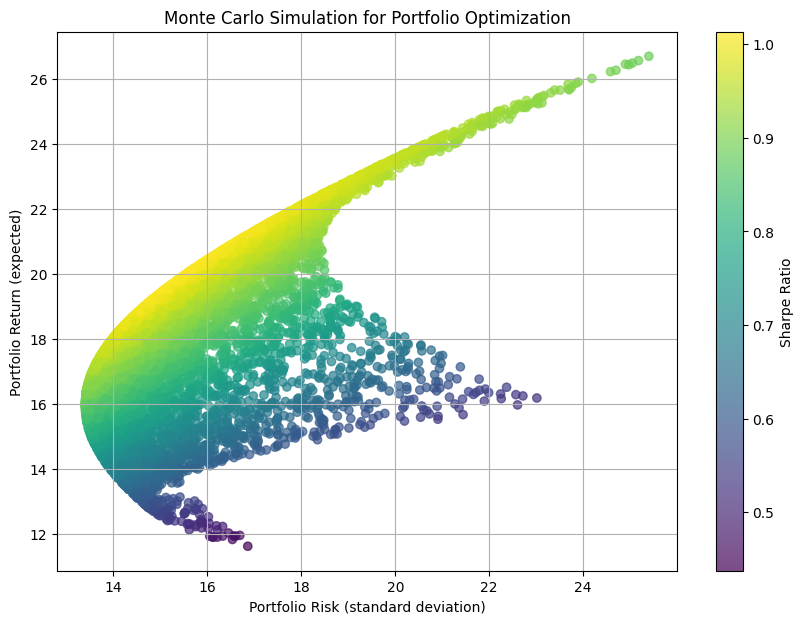

In [14]:
plot_portfolios(results_df)

# Identifying the Optimal Portfolio
The optimizer will search for a weight vector where:
* All weights range from 0 to 1 (long-only, max 100%)
* Sum of weights = 1 (full capital invested)
* Sharpe Ratio is maximized (by minimizing its negative value)

Additional Options:
* Allow short selling: change bounds to (-1, 1) or (-∞, ∞)
* Add target return or risk limit — include additional constraint(s)

In [15]:
def get_portfolio_analysis(mu, cov, risk_free_rate=risk_free_rate, points=50):
    np.random.seed(42)                                                          # Guaranteed Reproducibility
    num_assets = len(mu)
    initial_guess = np.ones(num_assets) / num_assets                            # Initial guess for optimizer. Assumes all assets are equally weighted (1/N) at the start.
    bounds = tuple((0, 1) for _ in range(num_assets))                           # This sets bounds for each weight (each stock/asset): 0 ≤ weight ≤ 1
                                                                                # This reflects a realistic, long-only portfolio with no leverage and means:
                                                                                # - An investor can't invest "negatively" (short selling is not allowed)
                                                                                # - Max position in one asset is 100%
    # Identifying the maximum Sharpe Ratio
    # It finds the highest return possible for every unit of risk you take.
    def neg_sharpe_ratio(weights):                                              # The function "knows" the weights because
                                                                                # the 'minimize' function automatically creates them and passes them into the objective functions.
        portfolio_return = np.dot(weights, mu)
        portfolio_std_dev  = np.sqrt(weights.T @ cov @ weights)
        return -(portfolio_return - risk_free_rate) / portfolio_std_dev

    const_sum = {'type': 'eq', 'fun': lambda x: np.sum(x) - 1}

    max_sharpe_ratio = minimize(neg_sharpe_ratio, initial_guess,
                                method='SLSQP',                                 # SLSQP = Sequential Least Squares Programming
                                bounds=bounds, constraints=const_sum)

    # Identifying the Global Minimum Variance
    # It finds the absolute starting point of the frontier (the lowest possible risk).
    min_risk_result = minimize(lambda w_min: np.sqrt(w_min @ cov @ w_min),      # Minimizing risk to find the most conservative portfolio
                       initial_guess,
                       constraints=const_sum,
                       bounds=bounds)
    min_risk_return = np.dot(min_risk_result.x, mu)
    min_risk_volatility = min_risk_result.fun                                   # .fun returns the final value of the objective function at the optimal point

    # Collecting Data for Efficient Frontier
    # Generating a range of target returns starting from the Global Minimum Variance portfolio up to the highest-yielding individual asset.
    target_returns = np.linspace(min_risk_return, mu.max(), points)             # It's a ruler generator. It creates a sequence of evenly spaced numbers between a start and an end point
    frontier_risks = []

    for target in target_returns:
        # 2 constraints: sum of weights = 1 and return = target
        const_target = {'type': 'eq', 'fun': lambda x, t=target: np.dot(x, mu) - t}
        constraints = [const_sum, const_target]

        # Minimizing the volatility
        result = minimize(lambda eff_weights: np.sqrt(eff_weights.T @ cov @ eff_weights),
                          initial_guess, method='SLSQP',
                          bounds=bounds, constraints=constraints)

        if result.success:
            frontier_risks.append(result.fun)
        else:
            frontier_risks.append(None) # In case the optomizer fails

    # Data for plotting the Efficient Frontier
    frontier_line = pd.DataFrame({'Return': target_returns, 'Risk': frontier_risks}).dropna()

    return max_sharpe_ratio, frontier_line, min_risk_return, min_risk_volatility

In [16]:
optimal_result, frontier_line, min_risk_return, min_risk_volatility = get_portfolio_analysis(mu, cov)
optimal_weights = optimal_result.x

print("Optimal Weights:", optimal_weights)
print("Expected Annual Return:", np.dot(optimal_weights, mu))
print("Expected Annual Risk:", np.sqrt(np.dot(optimal_weights.T, np.dot(cov, optimal_weights))))

Optimal Weights: [0.48783696 0.28770739 0.22445566]
Expected Annual Return: 19.9918214388046
Expected Annual Risk: 15.531967873291748


In [17]:
def plot_full_portfolio_view(frontier_line, results_df, optimal_weights, min_risk_return, min_risk_volatility, mu, cov, risk_free_rate=risk_free_rate):
    opt_return = np.dot(optimal_weights, mu)
    opt_risk = np.sqrt(optimal_weights.T @ cov @ optimal_weights)
    opt_sharpe = (opt_return - risk_free_rate) / opt_risk

    plt.figure(figsize=(12, 8))

    # Monte Carlo simulated portfolios
    scatter = plt.scatter(results_df['Risk'], results_df['Return'],
                          c=results_df['Sharpe Ratio'], cmap='viridis', alpha=0.6, s=10, zorder=1, label='Random Portfolios')
    plt.colorbar(scatter, label='Sharpe Ratio')

    # The Efficient Frontier
    plt.plot(frontier_line['Risk'],
    frontier_line['Return'], 'b', linewidth=2, label='Efficient Frontier')

    # The Optimal Portfolio
    plt.scatter(opt_risk, opt_return, color='black', marker='.', s=300, label='Optimal Portfolio (Max Sharpe)')
    plt.annotate(f'Optimal Portfolio: {opt_return/100:.2%}',
              xy=(opt_risk, opt_return),                                        # coordinates of the dot
              xytext=(opt_risk+1, opt_return),                                  # coordinates of the text
              fontsize=10, fontweight='bold')

    # The Global Minimum Variance POrtfolio
    plt.scatter(min_risk_volatility, min_risk_return, color='blue', marker='.', s=300, label='Global Minimum Variance')
    plt.annotate(f'Global Minimum Variance Portfolio: {min_risk_return/100:.2%}',
                 xy=(min_risk_volatility, min_risk_return),
                 xytext=(min_risk_volatility+0.5, min_risk_return),
                 fontsize=10)

    # The Risk-Free Rate
    plt.scatter(0, risk_free_rate, color='red', marker='.', s=300, label='Risk-Free Rate')
    plt.text(1, risk_free_rate, f'RFR = {risk_free_rate/100:.2%}',
             fontsize=10)

    # Capital Market Line (CML)
    x_vals = np.linspace(0, max(results_df['Risk'].max(), frontier_line['Risk'].max(), opt_risk) * 1.1, 100)
    y_vals = risk_free_rate + opt_sharpe * x_vals
    plt.plot(x_vals, y_vals, 'r--', linewidth=2, label='Capital Market Line')
    x_text = x_vals[-1] * 0.8
    y_text = risk_free_rate + opt_sharpe * x_text
    plt.text(x_text+1, y_text+2, 'CML', color='red', fontsize=14, rotation=39)

    plt.title('Efficient Frontier with Random Portfolios and Max Sharpe Portfolio')
    plt.xlabel('Portfolio Risk (Standard Deviation)')
    plt.ylabel('Portfolio Return (Expected Annual)')
    plt.legend()
    plt.grid(True)
    plt.show()

The Capital Market Line (CML) is a straight line that represents the new efficient frontier when a risk-free asset is added to a portfolio of risky assets. While the original Efficient Frontier is a curve consisting only of risky portfolios, the CML extends from the risk-free rate on the y-axis and runs tangent to that curve.

* **Asset Composition:** The Efficient Frontier includes only risky assets. The CML includes both the risk-free asset and the market portfolio.
* **Geometric Shape:** The Efficient Frontier is a curved line (hyperbola). The CML is a straight line.
* **Tangency Point:** The point where the CML touches the Efficient Frontier is the Tangency Portfolio, which represents the optimal market portfolio.
* **Efficiency:** Every point on the CML (except the tangency point) offers a superior risk-return profile compared to portfolios on the original curved Efficient Frontier.
* **Risk Measure:** Both concepts use standard deviation (total risk) as the primary measure of risk on the x-axis.

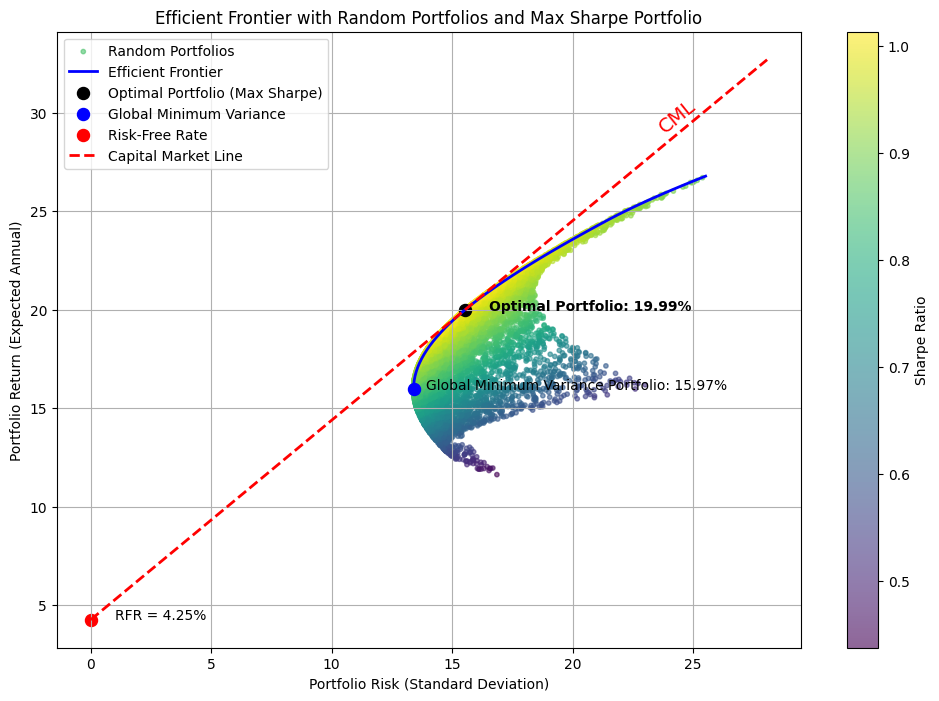

In [18]:
plot_full_portfolio_view(frontier_line, results_df, optimal_weights, min_risk_return, min_risk_volatility, mu, cov)

# This outcome serves as a classic illustration of Modern Portfolio Theory. It demonstrates that optimizing asset weights (the blue line) yields far superior results compared to a random allocation (the scatter plot).